In [1]:
import pandas as pd

df = pd.read_csv('Fake_Real_data.csv')

print(df.shape)

(9900, 2)


In [2]:
print(df.head())

                                                Text label
0   Top Trump Surrogate BRUTALLY Stabs Him In The...  Fake
1  U.S. conservative leader optimistic of common ...  Real
2  Trump proposes U.S. tax overhaul, stirs concer...  Real
3   Court Forces Ohio To Allow Millions Of Illega...  Fake
4  Democrats say Trump agrees to work on immigrat...  Real


In [3]:
df.label.value_counts()

label
Fake    5000
Real    4900
Name: count, dtype: int64

In [4]:
df['label_num'] = df['label'].map({'Fake':0 , 'Real':1})

In [5]:
df.head(10)

,Text,label,label_num
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake,0
1,U.S. conservative leader optimistic of common ...,Real,1
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real,1
3,Court Forces Ohio To Allow Millions Of Illega...,Fake,0
4,Democrats say Trump agrees to work on immigrat...,Real,1
5,France says pressure needed to stop North Kore...,Real,1
6,"Trump on Twitter (August 8): Opioid crisis, No...",Real,1
7,BUSTED: Trump Supporter Used Poll Watcher Cre...,Fake,0
8,Fatal Niger operation sparks calls for public ...,Real,1
9,Trump says he has 'great heart' for immigrant ...,Real,1


In [6]:
import spacy

nlp = spacy.load("en_core_web_lg")

In [7]:
df['vector'] = df['Text'].apply(lambda text: nlp(text).vector)

In [8]:
df.head(10)

,Text,label,label_num,vector
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake,0,"[-0.103623025, 0.17802684, -0.11873861, -0.034..."
1,U.S. conservative leader optimistic of common ...,Real,1,"[-0.0063406364, 0.16712041, -0.06661373, 0.017..."
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real,1,"[-0.122753024, 0.17192385, -0.024732638, -0.06..."
3,Court Forces Ohio To Allow Millions Of Illega...,Fake,0,"[-0.027337318, 0.12501417, -0.0073965387, -0.0..."
4,Democrats say Trump agrees to work on immigrat...,Real,1,"[-0.032708026, 0.093958504, -0.03287002, -0.00..."
5,France says pressure needed to stop North Kore...,Real,1,"[-0.0832948, 0.15191956, -0.0025734522, -0.007..."
6,"Trump on Twitter (August 8): Opioid crisis, No...",Real,1,"[-0.06610214, 0.16515954, -0.045601204, -0.017..."
7,BUSTED: Trump Supporter Used Poll Watcher Cre...,Fake,0,"[-0.044415116, 0.099440284, -0.0313871, -0.005..."
8,Fatal Niger operation sparks calls for public ...,Real,1,"[-0.07464975, 0.1665532, -0.016131256, -0.0327..."
9,Trump says he has 'great heart' for immigrant ...,Real,1,"[-0.05516354, 0.21813525, -0.1086625, -0.04640..."


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.vector.values,
    df.label_num,
    test_size=0.2,
    random_state=2022
)

In [10]:
import numpy as np

X_train_2d  = np.stack(X_train)
X_test_2d = np.stack(X_test)

In [12]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler()
scaled_train_embed = scaler.fit_transform(X_train_2d)
scaled_test_embed = scaler.transform(X_test_2d)

clf = MultinomialNB()
clf.fit(scaled_train_embed,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3976.,3944.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.69,-0.7 ]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 300)","[[2121.82,2166.78,1092.2 ,...,2351.54,2110.54,1824.66], [2100.6 ,1916.95,1628.04,...,2261.63,1922.77,1993.85]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 300)","[[-5.63,-5.61,-6.29,...,-5.52,-5.63,-5.78], [-5.64,-5.73,-5.89,...,-5.56,-5.73,-5.69]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,300


In [14]:
from sklearn.metrics import classification_report

y_pred = clf.predict(scaled_test_embed)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.96      0.96      1024
           1       0.95      0.95      0.95       956

    accuracy                           0.95      1980
   macro avg       0.95      0.95      0.95      1980
weighted avg       0.95      0.95      0.95      1980



In [15]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

clf.fit(X_train_2d,y_train)

y_pred = clf.predict(X_test_2d)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1024
           1       0.97      0.99      0.98       956

    accuracy                           0.98      1980
   macro avg       0.98      0.98      0.98      1980
weighted avg       0.98      0.98      0.98      1980



Python(76075) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sn

cm = confusion_matrix(y_test,y_pred)
cm

array([[990,  34],
       [ 13, 943]])

Text(95.72222222222221, 0.5, 'Truth')

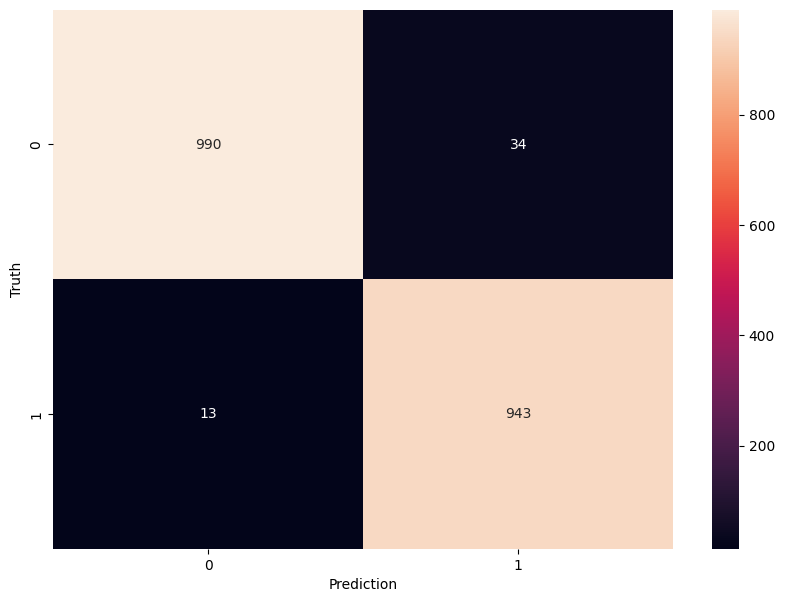

In [19]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Truth')